In [65]:
import random
import pandas as pd
import numpy as np

RANDOM_STATE = 123
random.seed(RANDOM_STATE)

N = 20
df_name = "AAPL_1min"

df = pd.read_csv(f'../datasets/{df_name}_marked.csv')

TRAIN_SIZE = int(0.9 * df.shape[0])
df_train, df_test = df[:TRAIN_SIZE], df[TRAIN_SIZE:]

In [66]:
def build_min_vectors_by_price(df, N, take_all=False):
    vectors = []
    n = df.shape[0]
    for i in range(N, n):
        if df.iloc[i]['is_min'] or take_all:
            cur_vec = []
            for j in range(i - 1, i - N, -1):
                cur_vec.append((df.iloc[j]['open'] - df.iloc[i]['open']) / df.iloc[i]['open'])
            vectors.append(cur_vec)
    return np.array(vectors)

def build_max_vectors_by_price(df, N, take_all=False):
    vectors = []
    n = df.shape[0]
    for i in range(N, n):
        if df.iloc[i]['is_max'] or take_all:
            cur_vec = []
            for j in range(i - 1, i - N, -1):
                cur_vec.append((df.iloc[j]['open'] - df.iloc[i]['open']) / df.iloc[i]['open'])
            vectors.append(cur_vec)
    return np.array(vectors)

X_train_min = build_min_vectors_by_price(df_train, N)
X_train_max = build_max_vectors_by_price(df_train, N)
print(X_train_min.shape, X_train_max.shape)

(105, 19) (116, 19)


***Сначала случай минимумов***

**Строим векторы отношений цен для трейна**

In [67]:
X_train_min[0]

array([ 0.00089462,  0.00058346,  0.00156366,  0.00203711,  0.00151476,
       -0.00015564, -0.0018283 , -0.00311207, -0.00073914, -0.00042798,
       -0.00163422, -0.00173108, -0.00202287, -0.00128377, -0.00021395,
       -0.00195986, -0.0014393 , -0.00093368, -0.00015564])

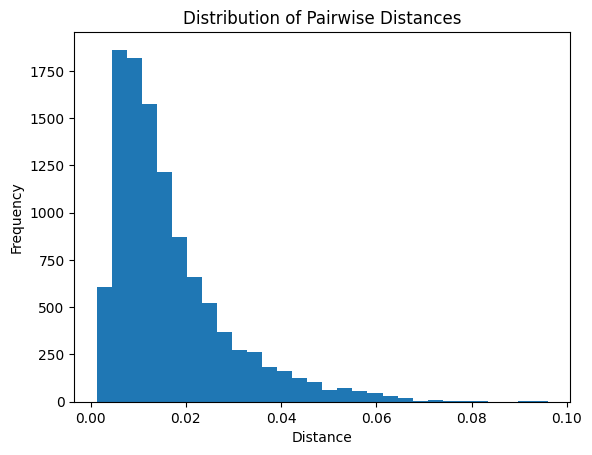

In [68]:
from matplotlib import pyplot as plt
from sklearn.metrics.pairwise import euclidean_distances

distances = euclidean_distances(X_train_min)

plt.hist([dist for row in distances for dist in row if dist > 0], bins=30)
plt.xlabel('Distance')
plt.ylabel('Frequency')
plt.title('Distribution of Pairwise Distances')
plt.show()

In [69]:
from sklearn.cluster import DBSCAN, KMeans

EPS = 0.01
clustering_dbscan = DBSCAN(eps=EPS, min_samples=5).fit(X_train_min)
clustering_dbscan.labels_

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0, -1, -1,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0, -1, -1,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0, -1,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0, -1,
        0,  0,  0])

In [70]:
noise = np.where(clustering_dbscan.labels_ == -1)[0]
noise

array([ 20,  21,  26,  59,  60,  75,  82,  93, 101])

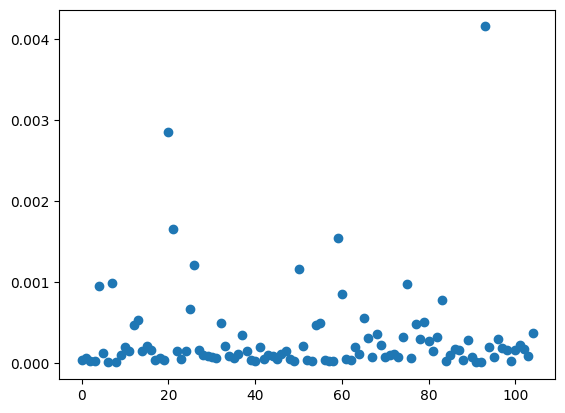

In [71]:
squared = np.diagonal(X_train_min @ X_train_min.T)
plt.scatter([i for i in range(squared.shape[0])], squared)
plt.show()

In [72]:
squared[noise]

array([0.00284578, 0.00164838, 0.00120746, 0.00154807, 0.00085767,
       0.00097781, 0.00032123, 0.00415157, 0.00022266])

In [73]:
clustering_kmeans = KMeans(n_clusters=2, random_state=RANDOM_STATE).fit(X_train_min)
clustering_kmeans.labels_

array([0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1], dtype=int32)

In [74]:
X_test = build_min_vectors_by_price(df_test, N, take_all=True)

**Проверяем DBSCAN метрики на тесте**

In [75]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score


def predict_dbscan(X_train, v, eps):
    distances = euclidean_distances([v], X_train[clustering_dbscan.core_sample_indices_])[0]
    
    min_dist_idx = np.argmin(distances)
    min_dist = distances[min_dist_idx]
    
    if min_dist <= eps:
        return clustering_dbscan.labels_[clustering_dbscan.core_sample_indices_[min_dist_idx]]
    else:
        return -1

y_true = df_test['is_min'][N:]
y_pred = []
for i in range(N, df_test.shape[0]):
    prediction = predict_dbscan(X_train_min, X_test[i - N], EPS)
    y_pred.append(prediction == -1)

accuracy = accuracy_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_pred)
print(f"DBSCAN - Accuracy: {accuracy:.4f}, Recall: {recall:.4f}, Precision: {precision:.4f}, F1 Score: {f1:.4f}, ROC_AUC: {roc_auc:.4f}")

DBSCAN - Accuracy: 0.9031, Recall: 0.2143, Precision: 0.0345, F1 Score: 0.0594, ROC_AUC: 0.5637


Если предсказывать явно (prediction != -1), получаем метрики:

Accuracy: 0.0969, Recall: 0.7857, Precision: 0.0123, F1 Score: 0.0243, ROC_AUC: 0.4363

Если же предсказывать инвертированный результат (prediction == -1):

Accuracy: 0.9031, Recall: 0.2143, Precision: 0.0345, F1 Score: 0.0594, ROC_AUC: 0.5637

Модель предсказывает инвертированное значение, хотя не сильно отличается от случайной

**Проверяем Kmeans метрики на тесте**

In [76]:
def predict_kmeans(v, threshold=None):
    label = clustering_kmeans.predict([v])[0]
    
    if threshold is not None:
        dist = euclidean_distances([v], [clustering_kmeans.cluster_centers_[label]])[0][0]
        if dist > threshold:
            return -1
    
    return label

y_true = df_test['is_min'][N:]
y_pred = []
for i in range(N, df_test.shape[0]):
    prediction = predict_kmeans(X_test[i - N], threshold=EPS)
    y_pred.append(prediction != -1)

accuracy = accuracy_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_pred)
print(f"Kmeans - Accuracy: {accuracy:.4f}, Recall: {recall:.4f}, Precision: {precision:.4f}, F1 Score: {f1:.4f}, ROC_AUC: {roc_auc:.4f}")

Kmeans - Accuracy: 0.3173, Recall: 0.7143, Precision: 0.0148, F1 Score: 0.0290, ROC_AUC: 0.5129


***Теперь аналогично для максимумов***

In [77]:
X_train_max[0]

array([-9.71612715e-05, -5.82579295e-04, -1.35920930e-03, -1.39808157e-03,
       -1.08733637e-03, -1.16508092e-03, -1.43683735e-03, -1.69896308e-03,
       -1.74754372e-03, -2.01941664e-03, -2.42709012e-03, -2.52425139e-03,
       -2.71837976e-03, -2.71837976e-03, -3.12616974e-03, -2.87375236e-03,
       -2.40767339e-03, -2.27183402e-03, -1.86404404e-03])

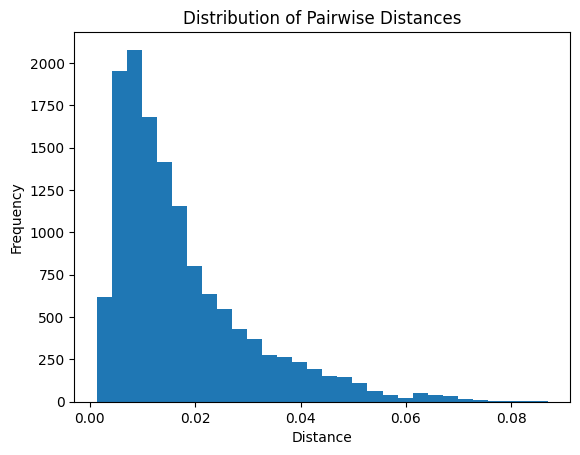

In [78]:
from matplotlib import pyplot as plt
from sklearn.metrics.pairwise import euclidean_distances

distances = euclidean_distances(X_train_max)

plt.hist([dist for row in distances for dist in row if dist > 0], bins=30)
plt.xlabel('Distance')
plt.ylabel('Frequency')
plt.title('Distribution of Pairwise Distances')
plt.show()

In [79]:
from sklearn.cluster import DBSCAN, KMeans

EPS = 0.01
clustering_dbscan = DBSCAN(eps=EPS, min_samples=5).fit(X_train_max)
clustering_dbscan.labels_

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0, -1,  0,  0,  0, -1, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0, -1, -1,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,
       -1,  0,  0,  0,  0,  0,  0,  0,  0, -1, -1,  0,  0,  0,  0,  0, -1,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0,
        0,  0, -1, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1,  0,  0])

In [80]:
noise = np.where(clustering_dbscan.labels_ == -1)[0]
noise

array([ 18,  22,  23,  37,  38,  45,  51,  60,  61,  67,  78,  87,  88,
        98, 113])

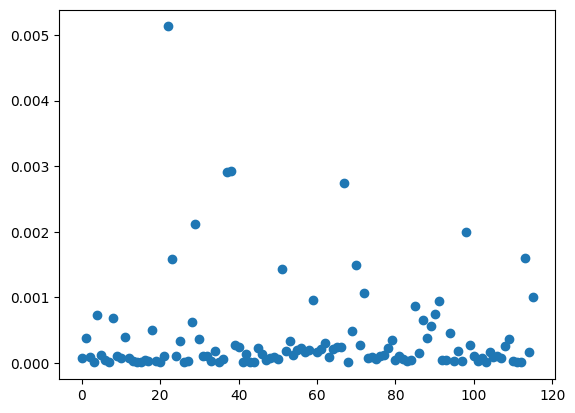

In [81]:
squared = np.diagonal(X_train_max @ X_train_max.T)
plt.scatter([i for i in range(squared.shape[0])], squared)
plt.show()

In [82]:
squared[noise]

array([0.00050844, 0.00512896, 0.00159219, 0.00291731, 0.00293212,
       0.00022216, 0.00143875, 0.00016658, 0.00022045, 0.00273819,
       0.00023627, 0.00065015, 0.00038455, 0.00199058, 0.00159489])

In [83]:
clustering_kmeans = KMeans(n_clusters=2, random_state=RANDOM_STATE).fit(X_train_max)
clustering_kmeans.labels_

array([0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 1], dtype=int32)

**Проверяем DBSCAN метрики на тесте**

In [84]:
def predict_dbscan(X_train, v, eps):
    distances = euclidean_distances([v], X_train[clustering_dbscan.core_sample_indices_])[0]
    
    min_dist_idx = np.argmin(distances)
    min_dist = distances[min_dist_idx]
    
    if min_dist <= eps:
        return clustering_dbscan.labels_[clustering_dbscan.core_sample_indices_[min_dist_idx]]
    else:
        return -1

y_true = df_test['is_max'][N:]
y_pred = []
for i in range(N, df_test.shape[0]):
    prediction = predict_dbscan(X_train_max, X_test[i - N], EPS)
    y_pred.append(prediction != -1)

accuracy = accuracy_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_pred)
print(f"DBSCAN - Accuracy: {accuracy:.4f}, Recall: {recall:.4f}, Precision: {precision:.4f}, F1 Score: {f1:.4f}, ROC_AUC: {roc_auc:.4f}")

DBSCAN - Accuracy: 0.2082, Recall: 0.8333, Precision: 0.0190, F1 Score: 0.0372, ROC_AUC: 0.5149


**Проверяем Kmeans метрики на тесте**

In [85]:
def predict_kmeans(v, threshold=None):
    label = clustering_kmeans.predict([v])[0]
    
    if threshold is not None:
        dist = euclidean_distances([v], [clustering_kmeans.cluster_centers_[label]])[0][0]
        if dist > threshold:
            return -1
    
    return label

y_true = df_test['is_max'][N:]
y_pred = []
for i in range(N, df_test.shape[0]):
    prediction = predict_kmeans(X_test[i - N], threshold=EPS)
    y_pred.append(prediction != -1)

accuracy = accuracy_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_pred)
print(f"Kmeans - Accuracy: {accuracy:.4f}, Recall: {recall:.4f}, Precision: {precision:.4f}, F1 Score: {f1:.4f}, ROC_AUC: {roc_auc:.4f}")

Kmeans - Accuracy: 0.6041, Recall: 0.6667, Precision: 0.0305, F1 Score: 0.0583, ROC_AUC: 0.6348
